# (μ + λ) Evolution Strategy — JSSP

In [ ]:
import numpy as np 
import random
import matplotlib.pyplot as plt
from time import time
from collections import Counter
from collections import defaultdict


## Read input file

In [2]:
def read_jobs(filename):
    with open(filename) as f:
        lines = f.read().split("\n")
    lines = [l.strip() for l in lines if l.strip()]
    num_jobs, num_machines = map(int, lines[0].split())
    jobs = []
    for i in range(1, num_jobs + 1):
        nums = list(map(int, lines[i].split()))
        ops = [(nums[j], nums[j+1]) for j in range(0, len(nums), 2)]
        jobs.append(ops)
    return jobs

## Fitness function — makespan (Cmax)

In [3]:
def makespan(jobs, chrom):
    job_op = [0] * len(jobs)
    job_time = [0] * len(jobs)
    machine_time = [0] * len(jobs[0])
    for job in chrom:
        m, d = jobs[job][job_op[job]]
        start = max(job_time[job], machine_time[m])
        end = start + d
        job_time[job] = end
        machine_time[m] = end
        job_op[job] += 1
    return max(machine_time)

## Chromosome initialisation

In [4]:
def random_chrom(num_jobs, num_machines):
    c = [j for j in range(num_jobs) for _ in range(num_machines)]
    random.shuffle(c)
    return c

## Mutation (swap)

In [5]:
def mutate(chrom):
    c = chrom[:]
    i, j = random.sample(range(len(c)), 2)
    c[i], c[j] = c[j], c[i]
    return c

## (μ + λ) main loop

In [6]:
def run(filename, mu=20, lam=100, generations=500, seed=42, stop_if_stagnant=1340):
    random.seed(seed)
    jobs = read_jobs(filename)
    num_jobs, num_machines = len(jobs), len(jobs[0])

    # Initialise mu parents
    parents = sorted([random_chrom(num_jobs, num_machines) for _ in range(mu)],
                     key=lambda c: makespan(jobs, c))
    best = parents[0][:]
    best_ms = makespan(jobs, best)
    print(f"Gen 0 | Makespan: {best_ms}")

    stop_no_improve = 0
    stop_last_best = best_ms

    for gen in range(1, generations + 1):

        # Generate lambda offspring (1 parent → 1 mutation → 1 child)
        offspring = []
        for _ in range(lam):
            parent = random.choice(parents)
            child = mutate(parent)
            offspring.append(child)

        # (mu + lambda): select best mu from parents + offspring
        parents = sorted(parents + offspring, key=lambda c: makespan(jobs, c))[:mu]

        ms = makespan(jobs, parents[0])
        if ms < best_ms:
            best_ms = ms
            best = parents[0][:]

        # Early stopping check
        if ms < stop_last_best:
            stop_last_best = ms
            stop_no_improve = 0
        else:
            stop_no_improve += 1
            if stop_no_improve >= stop_if_stagnant:
                print(f"Stopping early at gen {gen} (no improvement for {stop_if_stagnant} gens)")
                break

        if gen % 50 == 0:
            print(f"Gen {gen} | Makespan: {best_ms}")

    print(f"Best makespan: {best_ms}")
    return best, best_ms

## Run

In [7]:
filename = "abz5.txt"
run(filename)

Gen 0 | Makespan: 1845
Gen 50 | Makespan: 1318
Gen 100 | Makespan: 1318
Gen 150 | Makespan: 1318
Gen 200 | Makespan: 1318
Gen 250 | Makespan: 1318
Gen 300 | Makespan: 1318
Gen 350 | Makespan: 1318
Gen 400 | Makespan: 1318
Gen 450 | Makespan: 1318
Gen 500 | Makespan: 1318
Best makespan: 1318


([0,
  1,
  4,
  2,
  8,
  3,
  2,
  6,
  8,
  5,
  7,
  1,
  5,
  2,
  6,
  9,
  1,
  8,
  7,
  4,
  9,
  8,
  3,
  2,
  6,
  0,
  7,
  9,
  7,
  2,
  5,
  2,
  4,
  8,
  9,
  0,
  5,
  1,
  4,
  8,
  3,
  7,
  6,
  3,
  3,
  6,
  1,
  5,
  6,
  1,
  5,
  8,
  0,
  9,
  9,
  4,
  2,
  5,
  5,
  9,
  0,
  7,
  3,
  3,
  3,
  2,
  5,
  0,
  0,
  6,
  7,
  3,
  1,
  9,
  4,
  2,
  8,
  8,
  6,
  7,
  4,
  6,
  2,
  0,
  1,
  5,
  9,
  8,
  0,
  6,
  7,
  1,
  4,
  3,
  4,
  1,
  4,
  0,
  7,
  9],
 1318)


=== Instance abz5 ===
[abz5] Running es1...
[abz5.txt] Run 1/20 started...
[abz5.txt] Run 1/20 done. time=1.10s
[abz5.txt] Run 2/20 started...
[abz5.txt] Run 2/20 done. time=1.07s
[abz5.txt] Run 3/20 started...
[abz5.txt] Run 3/20 done. time=1.06s
[abz5.txt] Run 4/20 started...
[abz5.txt] Run 4/20 done. time=1.04s
[abz5.txt] Run 5/20 started...
[abz5.txt] Run 5/20 done. time=1.05s
[abz5.txt] Run 6/20 started...
[abz5.txt] Run 6/20 done. time=1.09s
[abz5.txt] Run 7/20 started...
[abz5.txt] Run 7/20 done. time=1.08s
[abz5.txt] Run 8/20 started...
[abz5.txt] Run 8/20 done. time=1.08s
[abz5.txt] Run 9/20 started...
[abz5.txt] Run 9/20 done. time=1.05s
[abz5.txt] Run 10/20 started...
[abz5.txt] Run 10/20 done. time=1.05s
[abz5.txt] Run 11/20 started...
[abz5.txt] Run 11/20 done. time=1.05s
[abz5.txt] Run 12/20 started...
[abz5.txt] Run 12/20 done. time=1.06s
[abz5.txt] Run 13/20 started...
[abz5.txt] Run 13/20 done. time=1.03s
[abz5.txt] Run 14/20 started...
[abz5.txt] Run 14/20 done. time

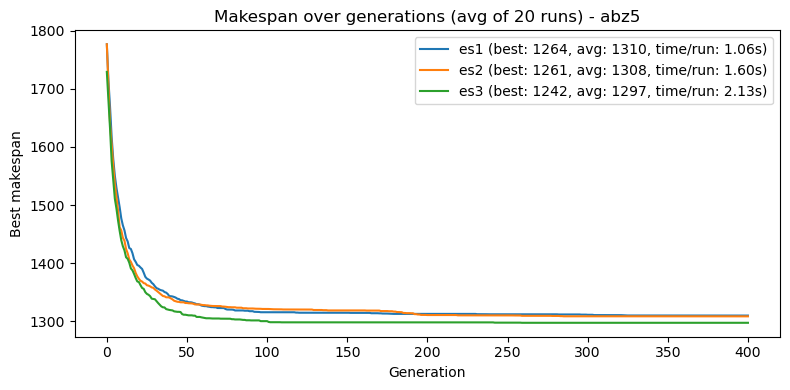


=== Instance abz6 ===
[abz6] Running es1...
[abz6.txt] Run 1/20 started...
[abz6.txt] Run 1/20 done. time=1.07s
[abz6.txt] Run 2/20 started...
[abz6.txt] Run 2/20 done. time=1.10s
[abz6.txt] Run 3/20 started...
[abz6.txt] Run 3/20 done. time=1.07s
[abz6.txt] Run 4/20 started...
[abz6.txt] Run 4/20 done. time=1.06s
[abz6.txt] Run 5/20 started...
[abz6.txt] Run 5/20 done. time=1.08s
[abz6.txt] Run 6/20 started...
[abz6.txt] Run 6/20 done. time=1.06s
[abz6.txt] Run 7/20 started...
[abz6.txt] Run 7/20 done. time=1.10s
[abz6.txt] Run 8/20 started...
[abz6.txt] Run 8/20 done. time=1.07s
[abz6.txt] Run 9/20 started...
[abz6.txt] Run 9/20 done. time=1.07s
[abz6.txt] Run 10/20 started...
[abz6.txt] Run 10/20 done. time=1.06s
[abz6.txt] Run 11/20 started...
[abz6.txt] Run 11/20 done. time=1.08s
[abz6.txt] Run 12/20 started...
[abz6.txt] Run 12/20 done. time=1.16s
[abz6.txt] Run 13/20 started...
[abz6.txt] Run 13/20 done. time=1.05s
[abz6.txt] Run 14/20 started...
[abz6.txt] Run 14/20 done. time

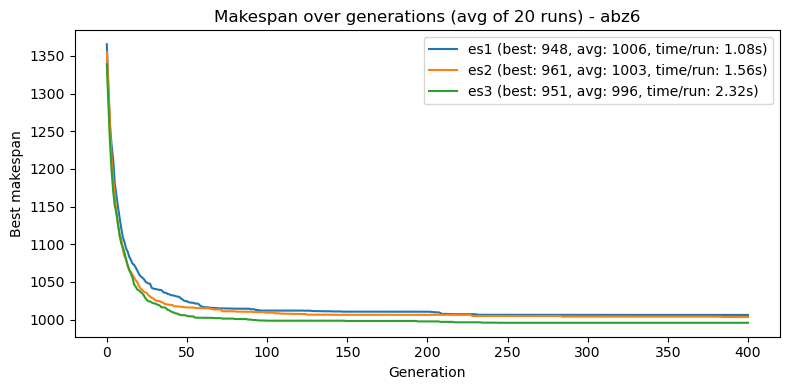


=== Instance abz7 ===
[abz7] Running es1...
[abz7.txt] Run 1/20 started...
[abz7.txt] Run 1/20 done. time=3.99s
[abz7.txt] Run 2/20 started...
[abz7.txt] Run 2/20 done. time=3.69s
[abz7.txt] Run 3/20 started...
[abz7.txt] Run 3/20 done. time=3.97s
[abz7.txt] Run 4/20 started...
[abz7.txt] Run 4/20 done. time=3.67s
[abz7.txt] Run 5/20 started...
[abz7.txt] Run 5/20 done. time=3.79s
[abz7.txt] Run 6/20 started...
[abz7.txt] Run 6/20 done. time=3.71s
[abz7.txt] Run 7/20 started...
[abz7.txt] Run 7/20 done. time=3.48s
[abz7.txt] Run 8/20 started...
[abz7.txt] Run 8/20 done. time=3.56s
[abz7.txt] Run 9/20 started...
[abz7.txt] Run 9/20 done. time=3.75s
[abz7.txt] Run 10/20 started...
[abz7.txt] Run 10/20 done. time=3.64s
[abz7.txt] Run 11/20 started...
[abz7.txt] Run 11/20 done. time=3.68s
[abz7.txt] Run 12/20 started...
[abz7.txt] Run 12/20 done. time=3.75s
[abz7.txt] Run 13/20 started...
[abz7.txt] Run 13/20 done. time=3.65s
[abz7.txt] Run 14/20 started...
[abz7.txt] Run 14/20 done. time

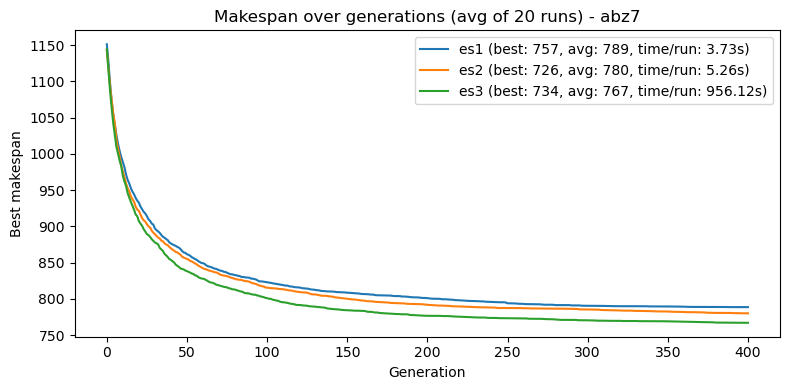

In [10]:
import random
import matplotlib.pyplot as plt
from time import time
from collections import Counter

def run_es_collect_curve(file_path, mu, lam, generations, runs=20):
    """Run (μ + λ) ES multiple times and collect convergence curves."""
    jobs = read_jobs(file_path)
    num_jobs, num_machines = len(jobs), len(jobs[0])
    
    all_curves = []
    run_times = []
    final_makespans = []
    
    for run_idx in range(1, runs + 1):
        print(f"[{file_path}] Run {run_idx}/{runs} started...")
        start_time = time()
        
        # Initialize mu parents
        parents = sorted([random_chrom(num_jobs, num_machines) for _ in range(mu)],
                         key=lambda c: makespan(jobs, c))
        best_curve = []
        best_ms = makespan(jobs, parents[0])
        best_curve.append(best_ms)
        
        for gen in range(1, generations + 1):
            # Generate lambda offspring (1 parent → 1 mutation → 1 child)
            offspring = []
            for _ in range(lam):
                parent = random.choice(parents)
                child = mutate(parent)
                offspring.append(child)
            
            # (μ + λ): select best mu from parents + offspring
            parents = sorted(parents + offspring, key=lambda c: makespan(jobs, c))[:mu]
            
            ms = makespan(jobs, parents[0])
            best_curve.append(ms)
            
            if ms < best_ms:
                best_ms = ms
        
        elapsed = time() - start_time
        run_times.append(elapsed)
        all_curves.append(best_curve)
        final_makespans.append(best_curve[-1])
        print(f"[{file_path}] Run {run_idx}/{runs} done. time={elapsed:.2f}s")
    
    avg_curve = [sum(gen_vals) / len(gen_vals) for gen_vals in zip(*all_curves)]
    avg_time_per_run = sum(run_times) / len(run_times) if run_times else 0.0
    return avg_curve, avg_time_per_run, run_times, final_makespans

# --- Parameter sets ---
es1 = dict(mu=20, lam=100, generations=400)
es2 = dict(mu=30, lam=150, generations=400)
es3 = dict(mu=40, lam=200, generations=400)

instances = [
    ("abz5.txt", "abz5"),
    ("abz6.txt", "abz6"),
    ("abz7.txt", "abz7"),
]

for path, label in instances:
    print(f"\n=== Instance {label} ===")
    
    print(f"[{label}] Running es1...")
    c1, t1_avg, t1_runs, f1 = run_es_collect_curve(path, runs=20, **es1)
    print(f"[{label}] es1 done. Final avg makespan: {c1[-1]:.2f} | best: {min(f1):.2f} | avg: {sum(f1)/len(f1):.2f} | avg time/run: {t1_avg:.2f}s")
    
    print(f"[{label}] Running es2...")
    c2, t2_avg, t2_runs, f2 = run_es_collect_curve(path, runs=20, **es2)
    print(f"[{label}] es2 done. Final avg makespan: {c2[-1]:.2f} | best: {min(f2):.2f} | avg: {sum(f2)/len(f2):.2f} | avg time/run: {t2_avg:.2f}s")
    
    print(f"[{label}] Running es3...")
    c3, t3_avg, t3_runs, f3 = run_es_collect_curve(path, runs=20, **es3)
    print(f"[{label}] es3 done. Final avg makespan: {c3[-1]:.2f} | best: {min(f3):.2f} | avg: {sum(f3)/len(f3):.2f} | avg time/run: {t3_avg:.2f}s")
    
    plt.figure(figsize=(8, 4))
    plt.plot(c1, label=f"es1 (best: {min(f1):.0f}, avg: {sum(f1)/len(f1):.0f}, time/run: {t1_avg:.2f}s)")
    plt.plot(c2, label=f"es2 (best: {min(f2):.0f}, avg: {sum(f2)/len(f2):.0f}, time/run: {t2_avg:.2f}s)")
    plt.plot(c3, label=f"es3 (best: {min(f3):.0f}, avg: {sum(f3)/len(f3):.0f}, time/run: {t3_avg:.2f}s)")
    plt.title(f"Makespan over generations (avg of 20 runs) - {label}")
    plt.xlabel("Generation")
    plt.ylabel("Best makespan")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Job Shop Scheduling Problem: ROA Group 14 (JSSP) 

# Trajectory based - Hill Climbing


In [ ]:
def parse_instance(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    lines = [line.strip() for line in lines if line.strip()]

    for i, line in enumerate(lines):
        if line[0].isdigit():
            jobs, machines = map(int, line.split())
            start_index = i + 1
            break

    jobs_data = []
    for line in lines[start_index:start_index + jobs]:
        numbers = list(map(int, line.split()))
        operations = []
        for i in range(0, len(numbers), 2):
            machine = numbers[i]
            duration = numbers[i + 1]
            operations.append((machine, duration))
        jobs_data.append(operations)

    return jobs, machines, jobs_data

In [ ]:
def makespan(chromosome, jobs, n_machines):
    n_jobs      = len(jobs)
    job_step    = [0] * n_jobs
    job_end     = [0] * n_jobs
    machine_end = [0] * n_machines
    schedule    = defaultdict(list)

    for job in chromosome:
        step = job_step[job]
        if step >= len(jobs[job]):
            continue
        machine, duration = jobs[job][step]
        start  = max(job_end[job], machine_end[machine])
        finish = start + duration
        schedule[machine].append((job, start, finish))
        machine_end[machine] = finish
        job_end[job]         = finish
        job_step[job]       += 1

    return max(machine_end), dict(schedule)


def random_chromosome(n_jobs, n_machines):
    chrom = [j for j in range(n_jobs) for _ in range(n_machines)]
    np.random.shuffle(chrom)
    return chrom


In [ ]:
def swap_adjacent(chrom):
    c = chrom[:]
    i = random.randrange(len(c) - 1)
    c[i], c[i+1] = c[i+1], c[i]
    return c


def insert_move(chrom):
    c = chrom[:]
    i = random.randrange(len(c))
    j = random.randrange(len(c))
    elem = c.pop(i)
    c.insert(j, elem)
    return c


def reverse_segment(chrom):
    c = chrom[:]
    i, j = sorted(random.sample(range(len(c)), 2))
    c[i:j+1] = c[i:j+1][::-1]
    return c


OPERATORS = [swap_adjacent, insert_move, reverse_segment]

In [ ]:
def hill_climbing(jobs, n_jobs, n_machines,
                  max_iter=10_000,
                  operator=None):

    current    = random_chromosome(n_jobs, n_machines)
    current_ms = makespan(current, jobs, n_machines)[0]
    history    = [current_ms]

    for _ in range(max_iter):
        op        = operator if operator else random.choice(OPERATORS)
        neighbour = op(current)
        nb_ms     = makespan(neighbour, jobs, n_machines)[0]

        if nb_ms <= current_ms:
            current    = neighbour
            current_ms = nb_ms

        history.append(current_ms)

    return current, current_ms, history


def random_restart_hill_climbing(jobs, n_jobs, n_machines,
                                  max_iter=10_000,
                                  n_restarts=10):

    iters_per_restart = max(1, max_iter // n_restarts)
    best_chrom   = None
    best_ms      = float('inf')
    full_history = []

    for restart in range(n_restarts):
        chrom, ms, hist = hill_climbing(
            jobs, n_jobs, n_machines,
            max_iter=iters_per_restart
        )
        full_history.extend(hist)

        if ms < best_ms:
            best_ms    = ms
            best_chrom = chrom[:]

    return best_chrom, best_ms, full_history



=== Instance abz5 ===
Jobs: 10 | Machines: 10 | Optimal: 1234
Single HC over 20 runs: best =   1242 | avg = 1269.3 | time/run = 0.75s
Random-Restart HC over 20 runs: best =   1262 | avg = 1288.7 | time/run = 0.73s
HC (swap_adjacent       ) best =   1307 | avg = 1393.0 | time/run = 0.68s
HC (insert_move         ) best =   1239 | avg = 1262.8 | time/run = 0.69s
HC (reverse_segment     ) best =   1252 | avg = 1290.5 | time/run = 0.75s


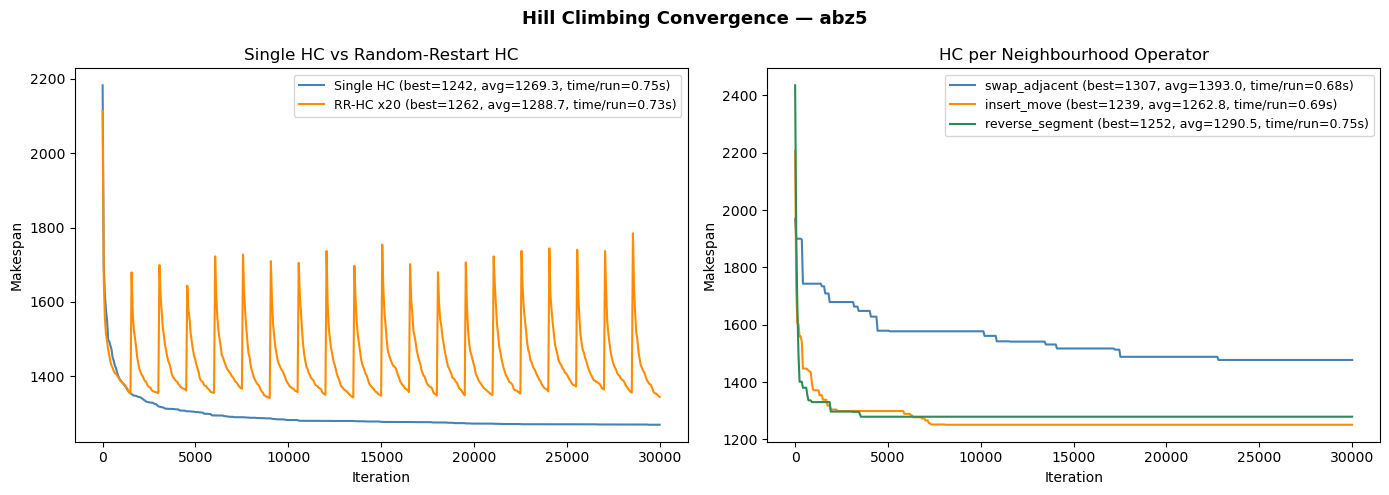

Over 20 runs:
  Best  : 1251
  Worst : 1307
  Mean  : 1278.5
  Std   : 12.4
  Avg gap from optimal: 3.6%


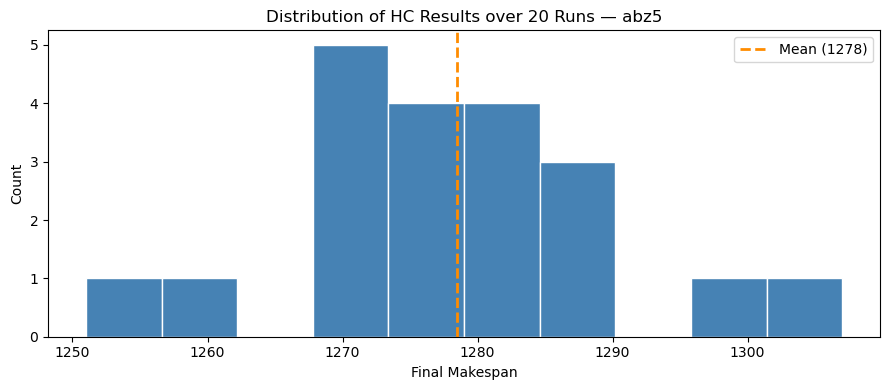


=== Instance abz6 ===
Jobs: 10 | Machines: 10 | Optimal: 943
Single HC over 20 runs: best =    947 | avg =  968.4 | time/run = 0.73s
Random-Restart HC over 20 runs: best =    971 | avg =  989.6 | time/run = 0.85s
HC (swap_adjacent       ) best =    967 | avg = 1071.0 | time/run = 0.74s
HC (insert_move         ) best =    943 | avg =  969.3 | time/run = 0.74s
HC (reverse_segment     ) best =    948 | avg =  981.5 | time/run = 0.80s


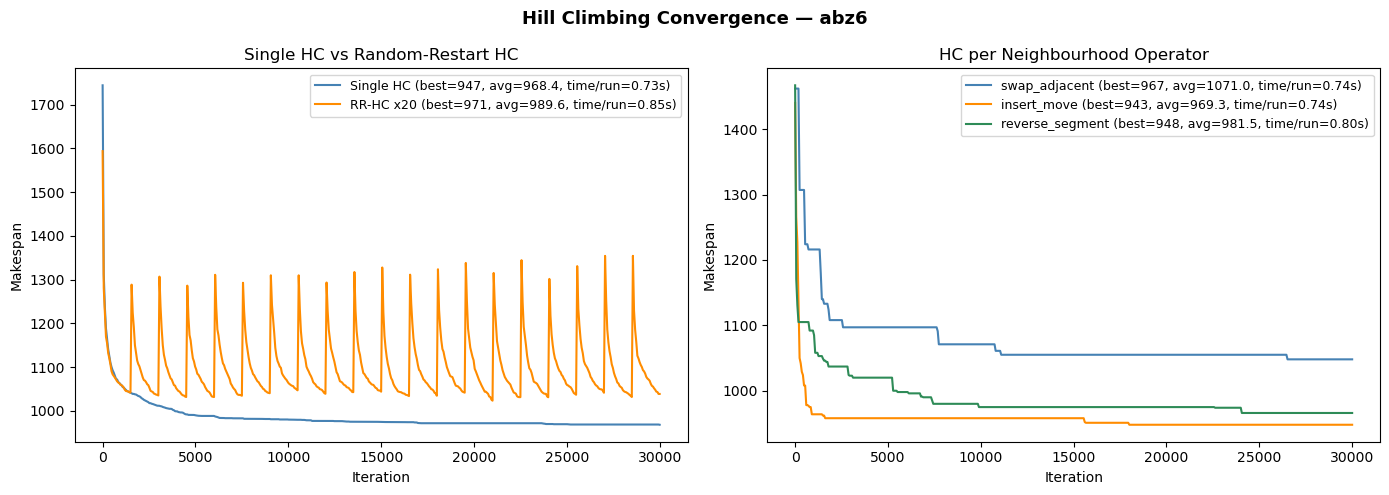

Over 20 runs:
  Best  : 943
  Worst : 1000
  Mean  : 964.8
  Std   : 15.7
  Avg gap from optimal: 2.3%


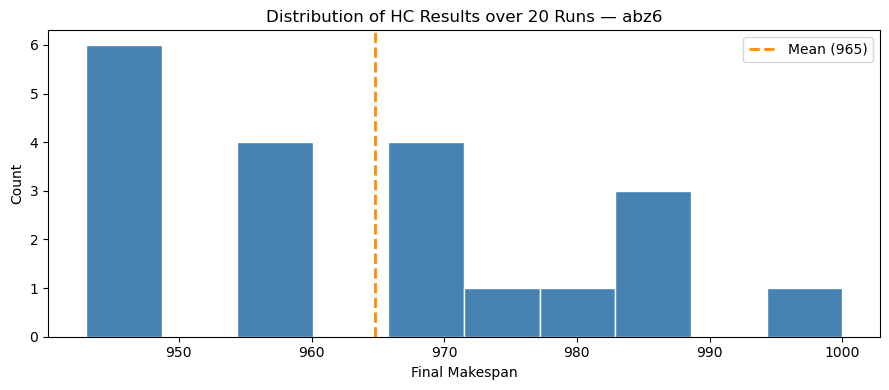


=== Instance abz7 ===
Jobs: 20 | Machines: 15 | Optimal: 656
Single HC over 20 runs: best =    710 | avg =  735.2 | time/run = 2.19s
Random-Restart HC over 20 runs: best =    807 | avg =  829.9 | time/run = 2.27s
HC (swap_adjacent       ) best =    870 | avg =  944.3 | time/run = 2.17s
HC (insert_move         ) best =    695 | avg =  720.0 | time/run = 2.46s
HC (reverse_segment     ) best =    751 | avg =  795.2 | time/run = 2.59s


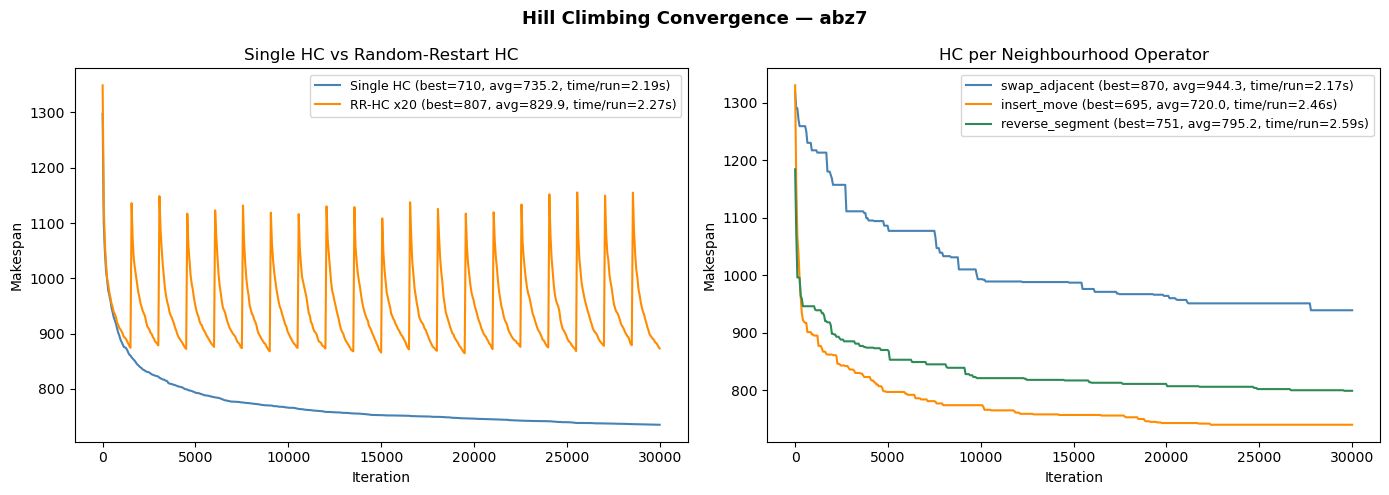

Over 20 runs:
  Best  : 714
  Worst : 765
  Mean  : 738.9
  Std   : 12.1
  Avg gap from optimal: 12.6%


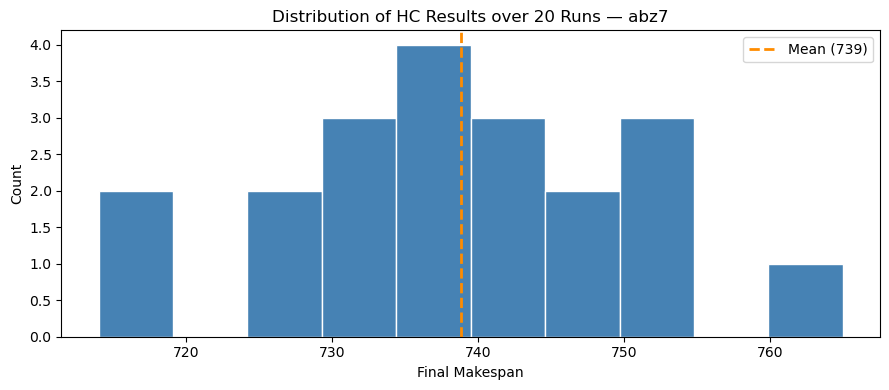

In [ ]:
KNOWN_OPTIMAL = {
    'ft06': 55, 'ft10': 930, 'ft20': 1165,
    'la01': 666, 'la02': 655, 'la03': 597,
    'abz5': 1234, 'abz6': 943, 'abz7': 656,  # add if known
}

MAX_ITER = 30_000
RESTARTS = 20
N_RUNS  = 20
HC_RR_RUNS = 20

def run_hc_suite(file_path, label):
    n_jobs, n_machines, jobs = parse_instance(file_path)
    opt = KNOWN_OPTIMAL.get(label)

    print(f"\n=== Instance {label} ===")
    print(f"Jobs: {n_jobs} | Machines: {n_machines} | Optimal: {opt}")

    # 1) Single HC (averaged over HC_RR_RUNS)
    hc_histories = []
    hc_makespans = []
    hc_times = []
    for _ in range(HC_RR_RUNS):
        t0 = time.time()
        _, hc_ms, hc_hist = hill_climbing(jobs, n_jobs, n_machines, max_iter=MAX_ITER)
        hc_times.append(time.time() - t0)
        hc_makespans.append(hc_ms)
        hc_histories.append(hc_hist)

    hc_best = min(hc_makespans)
    hc_avg = np.mean(hc_makespans)
    hc_time_avg = np.mean(hc_times)
    hc_hist_avg = [np.mean(vals) for vals in zip(*hc_histories)]

    print(f"Single HC over {HC_RR_RUNS} runs: best = {hc_best:6d} | avg = {hc_avg:6.1f} | time/run = {hc_time_avg:.2f}s")

    # 2) Random-Restart HC (averaged over HC_RR_RUNS)
    rr_histories = []
    rr_makespans = []
    rr_times = []
    for _ in range(HC_RR_RUNS):
        t0 = time.time()
        _, rr_ms, rr_hist = random_restart_hill_climbing(
            jobs, n_jobs, n_machines, max_iter=MAX_ITER, n_restarts=RESTARTS
        )
        rr_times.append(time.time() - t0)
        rr_makespans.append(rr_ms)
        rr_histories.append(rr_hist)

    rr_best = min(rr_makespans)
    rr_avg = np.mean(rr_makespans)
    rr_time_avg = np.mean(rr_times)
    rr_hist_avg = [np.mean(vals) for vals in zip(*rr_histories)]

    print(f"Random-Restart HC over {HC_RR_RUNS} runs: best = {rr_best:6d} | avg = {rr_avg:6.1f} | time/run = {rr_time_avg:.2f}s")

    # 3) Per-operator HC
    op_results = {}
    for op in OPERATORS:
        op_run_results = []
        op_hist_sample = None
        op_times = []  # ADDED

        for _ in range(N_RUNS):
            t0 = time.time()  # ADDED
            _, op_ms, op_hist = hill_climbing(
                jobs, n_jobs, n_machines, max_iter=MAX_ITER, operator=op
            )
            op_times.append(time.time() - t0)  # ADDED
            op_run_results.append(op_ms)
            if op_hist_sample is None:
                op_hist_sample = op_hist

        op_best = min(op_run_results)
        op_avg = np.mean(op_run_results)
        op_time_avg = np.mean(op_times)  # ADDED

        op_results[op.__name__] = (op_best, op_avg, op_time_avg, op_hist_sample)  # CHANGED
        print(f"HC ({op.__name__:<20}) best = {op_best:6d} | avg = {op_avg:6.1f} | time/run = {op_time_avg:.2f}s")  # CHANGED


    # Plot convergence
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Hill Climbing Convergence — {label}", fontsize=13, fontweight='bold')

    ax = axes[0]
    step = max(1, len(hc_hist_avg) // 500)
    ax.plot(range(0, len(hc_hist_avg), step),
            [hc_hist_avg[i] for i in range(0, len(hc_hist_avg), step)],
            color='steelblue', lw=1.5,
            label=f'Single HC (best={hc_best}, avg={hc_avg:.1f}, time/run={hc_time_avg:.2f}s)')  # CHANGED
    step2 = max(1, len(rr_hist_avg) // 500)
    ax.plot(range(0, len(rr_hist_avg), step2),
            [rr_hist_avg[i] for i in range(0, len(rr_hist_avg), step2)],
            color='darkorange', lw=1.5,
            label=f'RR-HC x{RESTARTS} (best={rr_best}, avg={rr_avg:.1f}, time/run={rr_time_avg:.2f}s)')  # CHANGED
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Makespan")
    ax.set_title("Single HC vs Random-Restart HC")
    ax.legend(fontsize=9)

    ax = axes[1]
    colors = ['steelblue', 'darkorange', 'seagreen']
    for (name, (best_ms, avg_ms, time_avg, hist)), color in zip(op_results.items(), colors):  # CHANGED
        step = max(1, len(hist) // 500)
        ax.plot(range(0, len(hist), step),
                [hist[i] for i in range(0, len(hist), step)],
                color=color, lw=1.5,
                label=f'{name} (best={best_ms}, avg={avg_ms:.1f}, time/run={time_avg:.2f}s)')  # CHANGED
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Makespan")
    ax.set_title("HC per Operator")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Distribution over runs
    run_results = []
    for _ in range(N_RUNS):
        _, ms, _ = hill_climbing(jobs, n_jobs, n_machines, max_iter=MAX_ITER)
        run_results.append(ms)

    print(f"Over {N_RUNS} runs:")
    print(f"  Best  : {min(run_results)}")
    print(f"  Worst : {max(run_results)}")
    print(f"  Mean  : {np.mean(run_results):.1f}")
    print(f"  Std   : {np.std(run_results):.1f}")
    if opt:
        gaps = [(r - opt) / opt * 100 for r in run_results]
        print(f"  Avg gap from optimal: {np.mean(gaps):.1f}%")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(run_results, bins=10, color='steelblue', edgecolor='white')
    ax.axvline(np.mean(run_results), color='darkorange', ls='--', lw=2,
               label=f'Mean ({np.mean(run_results):.0f})')
    ax.set_xlabel("Final Makespan")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of HC Results over {N_RUNS} Runs — {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()


instances = [
    ("abz5.txt", "abz5"),
    ("abz6.txt", "abz6"),
    ("abz7.txt", "abz7"),
]

for path, label in instances:
    run_hc_suite(path, label)
